In [1]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed-pseudo/interaction_type_bout.csv')
df1['condition'] = 'artificial'


df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/group-housed/interaction_type_bout.csv')
df2['condition'] = 'grouped'

df = pd.concat([df1, df2], ignore_index=True)


/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_77475/3627116270.py:14: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[1, 1, 1, 1])


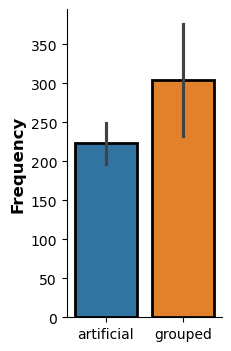

In [2]:
plt.figure(figsize=(2,4))
grouped = (
    df.groupby(['condition', 'file'])['bout_id']
      .size()
      .reset_index(name='num_bouts')
)

sns.barplot(data=grouped, x='condition', y='num_bouts', hue='condition', edgecolor='black', linewidth=2, errorbar='sd')

plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
sns.despine()

plt.tight_layout(rect=[1, 1, 1, 1])
plt.ylim(0, None)
plt.show()

/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_77475/1655919023.py:11: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout(rect=[1, 1, 1, 1])


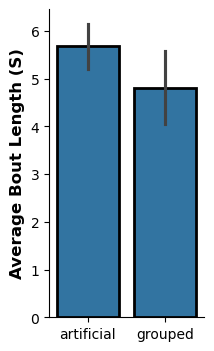

In [3]:
length_bouts = df.groupby(['condition', 'file'])['duration'].mean().reset_index(name='length_bout')



plt.figure(figsize=(2,4))
sns.barplot(data=length_bouts, x='condition', y='length_bout',  edgecolor='black', linewidth=2, errorbar='sd')
plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('Average Bout Length (S)', fontsize=12, fontweight='bold')
# plt.title('Average Contact Bout Length', fontsize=16, fontweight='bold')
sns.despine()
plt.tight_layout(rect=[1, 1, 1, 1])
plt.ylim(0, None)

plt.show()

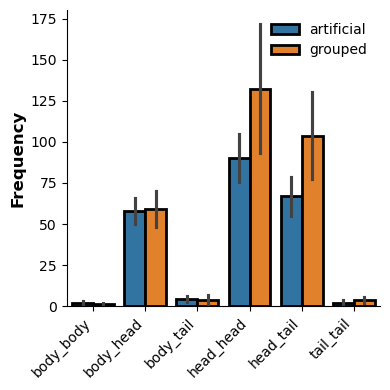

In [4]:
plt.figure(figsize=(4,4))
num_type = (
    df.groupby(['condition', 'file', 'initial_type'])['bout_id']
      .size()
      .unstack(fill_value=0)
      .stack()
      .reset_index(name='num_bouts')
)

sns.barplot(data=num_type, x='initial_type', y='num_bouts', hue='condition', edgecolor='black', linewidth=2, errorbar='sd')

plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
sns.despine()
plt.xticks(rotation=45, ha='right')
plt.legend(frameon=False, title=None)
plt.tight_layout()
plt.ylim(0, None)
plt.show()

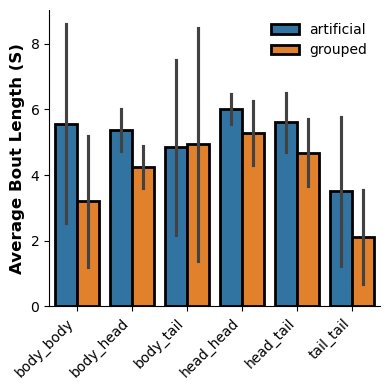

In [5]:
length_type = (
    df.groupby(['condition', 'file', 'initial_type'])['duration']
      .mean()
      .reset_index(name='length_bout')
)

plt.figure(figsize=(4,4))
sns.barplot(data=length_type, x='initial_type', y='length_bout', hue='condition', edgecolor='black', linewidth=2, errorbar='sd')

plt.xlabel('', fontsize=12, fontweight='bold')
plt.ylabel('Average Bout Length (S)', fontsize=12, fontweight='bold')
sns.despine()
plt.xticks(rotation=45, ha='right')
plt.legend(frameon=False, title=None)
plt.tight_layout()
plt.ylim(0, None)
plt.show()